
# Data Science Mini Project

Student Name:KARTHIK D

Batch: DS AN B03

Project Title: Semiconductor Manufacturing Quality Prediction Using Machine Learning

Submission Date:

## Project Title

### Semiconductor Manufacturing Quality Prediction Using Machine Learning

## Project Overview

Semiconductor manufacturing involves many sensors that continuously monitor the manufacturing process.

A small change in temperature, pressure, voltage, chemical conditions, or other process measurements can affect the final manufacturing result.

In this project, we use sensor measurements to predict whether a semiconductor manufacturing process result is:

- **Pass** — the process result is acceptable
- **Fail** — the process result is defective

The main goal is to build a Machine Learning classification system that can learn patterns from historical sensor data and predict the quality outcome for new observations.

### Business Problem

If a manufacturing process can be identified as potentially failing early, engineers can investigate the process before more defective products are produced.

Therefore, our Machine Learning workflow is:

Dataset
→ Data Understanding
→ EDA
→ Data Cleaning
→ Preprocessing
→ Feature Selection
→ Model Building
→ Model Evaluation
→ Final Model
→ Deployment

## STEP 1 — Dataset Understanding

### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load dataset

In [2]:
df=pd.read_csv("../data/SECOM_Predictive_Quality.csv")

In [3]:
df.head()

,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,sensor_010,...,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,target,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,Pass,19/07/2008 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,Pass,19/07/2008 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,Fail,19/07/2008 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,Pass,19/07/2008 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,Pass,19/07/2008 15:22:00


In [4]:
df.tail()

,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,sensor_010,...,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,target,timestamp
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,Pass,16/10/2008 15:13:00
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,Pass,16/10/2008 20:49:00
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,Pass,17/10/2008 05:26:00
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,Pass,17/10/2008 06:01:00
1566,2944.92,2450.76,2195.4444,2914.1792,1.5978,100.0,85.1011,0.1235,NaN,NaN,...,0.4987,0.0181,0.0040,3.6275,0.0117,0.0162,0.0045,137.7844,Pass,17/10/2008 06:07:00


### Why are we checking the first and last few rows?

Before performing any Machine Learning operation, we need to make sure that the dataset has been loaded correctly.

`head()` helps us understand:

- What the columns look like
- What type of values are present
- Whether the data was loaded correctly

`tail()` allows us to inspect the end of the dataset and make sure the file was not loaded incorrectly or truncated.

This is the first step in understanding the structure of our data.

### 3. Check shape

In [5]:
print("Rows : ",df.shape[0])
print("Columns : ",df.shape[1])

Rows :  1567
Columns :  592


### 4. Understand columns

In [6]:
df.dtypes

sensor_001    float64
sensor_002    float64
sensor_003    float64
sensor_004    float64
sensor_005    float64
               ...   
sensor_588    float64
sensor_589    float64
sensor_590    float64
target            str
timestamp         str
Length: 592, dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, sensor_001 to timestamp
dtypes: float64(590), str(2)
memory usage: 7.1 MB


### 5. Check target

In [8]:
df['target'].value_counts()

target
Pass    1463
Fail     104
Name: count, dtype: int64

In [9]:
df['target'].value_counts(normalize=True)*100

target
Pass    93.363114
Fail     6.636886
Name: proportion, dtype: float64

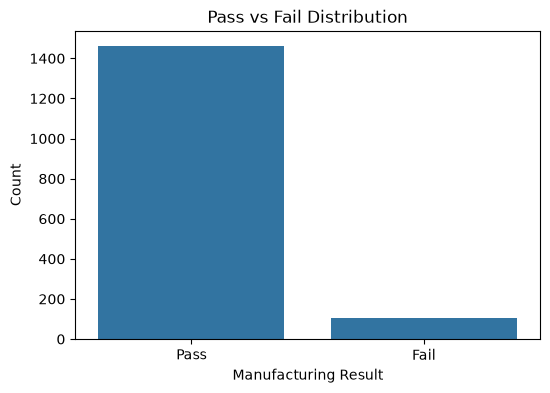

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="target")

plt.title("Pass vs Fail Distribution")
plt.xlabel("Manufacturing Result")
plt.ylabel("Count")

plt.show()

### Why do we check the target distribution?

Our target variable represents the final manufacturing result:

- `Pass`
- `Fail`

Before building a classification model, we need to understand whether both classes are represented reasonably in the dataset.

The dataset contains significantly more Pass observations than Fail observations.

This means that the target variable is **imbalanced**.

### Why is this important?

Suppose a model predicts `Pass` for almost every observation.

Because Pass is the majority class, the model could still achieve high accuracy while failing to identify actual defective processes.

Therefore, we cannot depend on accuracy alone.

For this project, we will also use:

- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

Special attention will be given to the **Fail class**, because identifying potential failures is important in a manufacturing environment.

### 6. Check missing values

In [11]:
missing=df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing.head(20)

sensor_293    1429
sensor_158    1429
sensor_159    1429
sensor_294    1429
sensor_493    1341
sensor_221    1341
sensor_359    1341
sensor_086    1341
sensor_517    1018
sensor_518    1018
sensor_383    1018
sensor_112    1018
sensor_384    1018
sensor_385    1018
sensor_247    1018
sensor_245    1018
sensor_246    1018
sensor_111    1018
sensor_519    1018
sensor_110    1018
dtype: int64

In [12]:
missing_percentage=(df.isnull().mean()*100).sort_values(ascending=False)
missing_percentage.head(20)

sensor_293    91.193363
sensor_294    91.193363
sensor_158    91.193363
sensor_159    91.193363
sensor_493    85.577537
sensor_221    85.577537
sensor_086    85.577537
sensor_359    85.577537
sensor_111    64.964901
sensor_518    64.964901
sensor_383    64.964901
sensor_247    64.964901
sensor_385    64.964901
sensor_384    64.964901
sensor_246    64.964901
sensor_245    64.964901
sensor_112    64.964901
sensor_110    64.964901
sensor_517    64.964901
sensor_519    64.964901
dtype: float64

### 7. Check duplicates

In [13]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


### 8. Descriptive statistics

In [14]:
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
sensor_001,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.49000,3056.650000,3356.3500
sensor_002,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.40500,2538.822500,2846.4400
sensor_003,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.06670,2218.055500,2315.2667
sensor_004,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.21440,1591.223500,3715.0417
sensor_005,1553.0,4.197013,56.355540,0.6815,1.017700,1.31680,1.525700,1114.5366
sensor_006,1553.0,100.000000,0.000000,100.0000,100.000000,100.00000,100.000000,100.0000
sensor_007,1553.0,101.112908,6.237214,82.1311,97.920000,101.51220,104.586700,129.2522
sensor_008,1558.0,0.121822,0.008961,0.0000,0.121100,0.12240,0.123800,0.1286
sensor_009,1565.0,1.462862,0.073897,1.1910,1.411200,1.46160,1.516900,1.6564
sensor_010,1565.0,-0.000841,0.015116,-0.0534,-0.010800,-0.00130,0.008400,0.0749


### 9. Check timestamp

In [15]:
print(df['timestamp'].dtype)

str


In [16]:
df['timestamp']=pd.to_datetime(df['timestamp'],errors="coerce")

C:\Users\Varshini D\AppData\Local\Temp\ipykernel_22132\2322532092.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['timestamp']=pd.to_datetime(df['timestamp'],errors="coerce")


In [17]:
print(df['timestamp'].dtype)

datetime64[us]


### 10. Separate x and y

In [18]:
x = df.drop(columns=["target", "timestamp"])
y = df["target"]

In [19]:
print(x.shape)
print(y.shape)

(1567, 590)
(1567,)


## Step 2 --- EDA , Data Preprocessing & Feature Engineering

### 11 Missing Value Analysis

In [20]:
total_missing=df.isnull().sum().sum()
total_size=df.size
missing_percentage=(total_missing/total_size)*100
print("Total Missing Values :",total_missing)
print("Over All Missing Percentage :",missing_percentage)

Total Missing Values : 41951
Over All Missing Percentage : 4.522219251798065


Now find features with missing values:

In [21]:
missing.head(20)

sensor_293    1429
sensor_158    1429
sensor_159    1429
sensor_294    1429
sensor_493    1341
sensor_221    1341
sensor_359    1341
sensor_086    1341
sensor_517    1018
sensor_518    1018
sensor_383    1018
sensor_112    1018
sensor_384    1018
sensor_385    1018
sensor_247    1018
sensor_245    1018
sensor_246    1018
sensor_111    1018
sensor_519    1018
sensor_110    1018
dtype: int64

Visualize top missing features

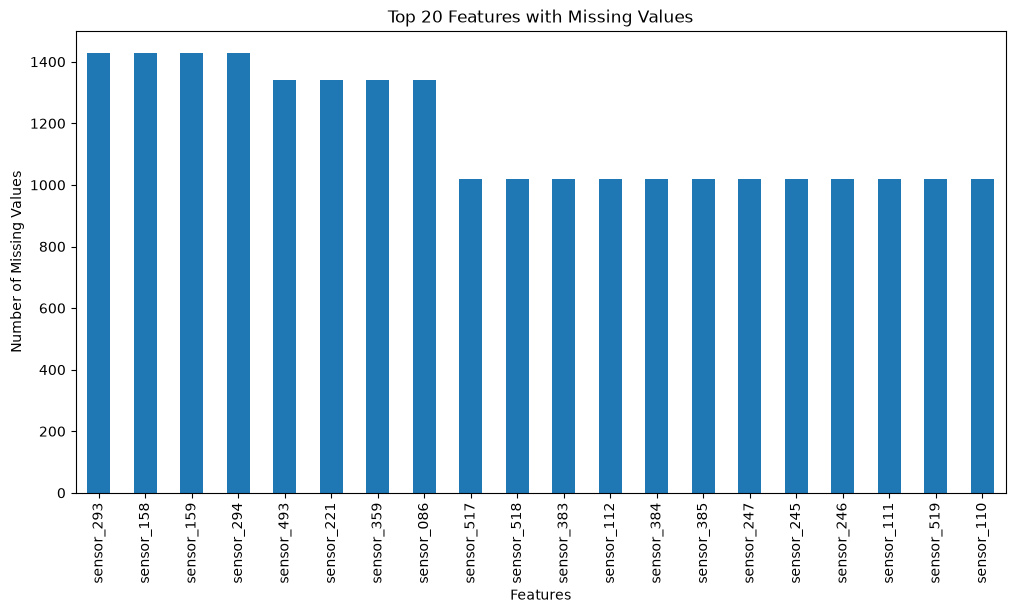

In [22]:
plt.figure(figsize=(12, 6))

missing.head(20).plot(kind="bar")

plt.title("Top 20 Features with Missing Values")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.show()

Why?

In a manufacturing environment, missing sensor readings can happen because of:

sensor failure

measurement unavailable

equipment issue

data collection problem

### 12 Feature Distribution

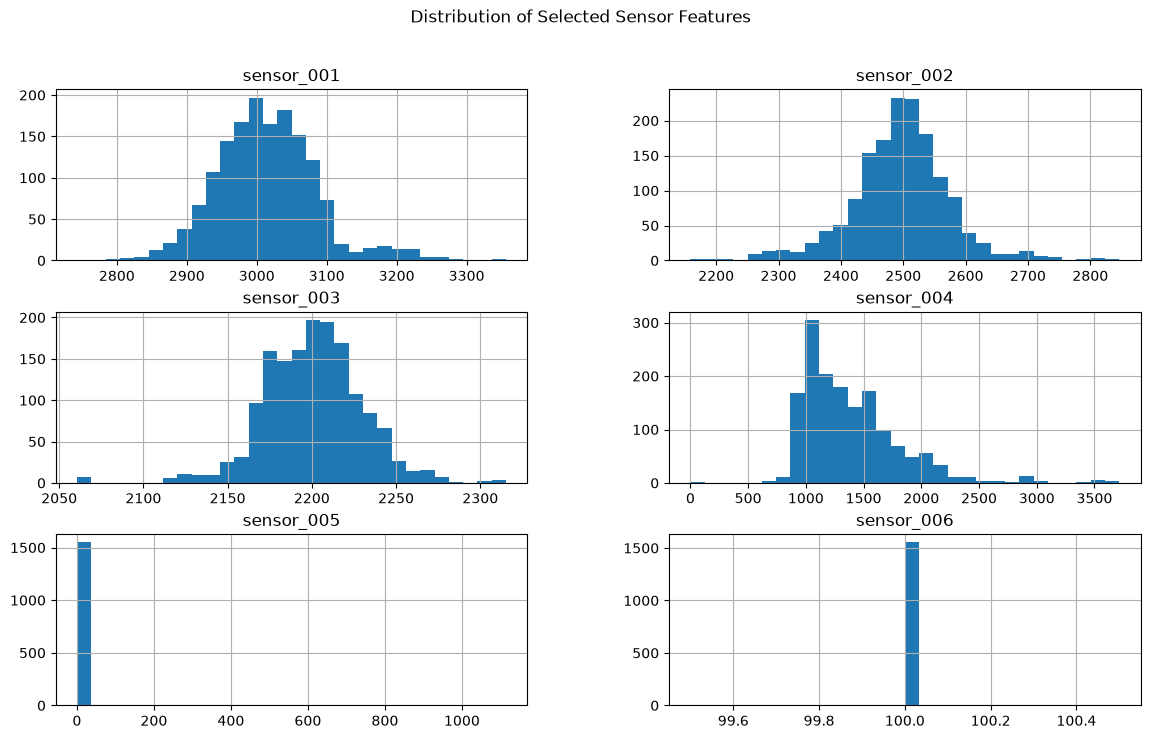

In [23]:
features_to_plot = x.columns[:6]

df[features_to_plot].hist(
    figsize=(14, 8),
    bins=30
)

plt.suptitle("Distribution of Selected Sensor Features")

plt.show()

### 13 Statistical Summary

In [24]:
stats=x.describe().T

In [25]:
low_variance=stats[stats['std']<0.01]
print("low variance Features :",len(low_variance))

low variance Features : 171


### 14 Check Constant Features

In [26]:
constant_features=[col for col in x.columns if df[col].nunique(dropna=False)<=1]
print("Constant features :",len(constant_features))

Constant features : 0


### Why do we check constant features?

A constant feature has the same value for every observation.

Such a feature cannot help a Machine Learning model distinguish between Pass and Fail because it contains no variation.

### Result

No constant features were found.

Therefore, there were no completely constant sensor features that needed to be removed.

### 15 Outlier Analysis

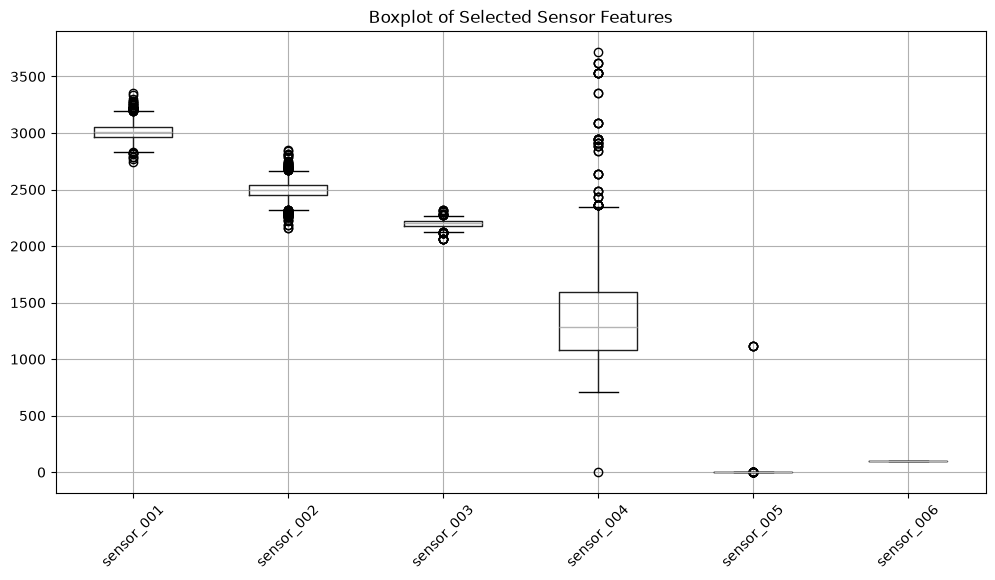

In [27]:
selected_features = x.columns[:6]

plt.figure(figsize=(12, 6))

x[selected_features].boxplot()

plt.title("Boxplot of Selected Sensor Features")
plt.xticks(rotation=45)

plt.show()

### 16 Skewness Analysis

In [28]:
skewness = x.skew(numeric_only=True)

skewness = skewness.sort_values(
    key=abs,
    ascending=False
)

skewness.head(20)

sensor_391    39.562779
sensor_253    39.560364
sensor_288    39.521337
sensor_153    39.519611
sensor_210    39.509493
sensor_075    39.509493
sensor_479    39.509493
sensor_343    39.509493
sensor_348    39.509493
sensor_207    39.509493
sensor_525    38.854591
sensor_284    38.622570
sensor_149    38.537455
sensor_118    38.005963
sensor_422    37.672728
sensor_017    37.034763
sensor_426    36.223347
sensor_322    30.855098
sensor_186    30.699402
sensor_421    30.345885
dtype: float64

In [29]:
highly_skewed=skewness[abs(skewness)>1]
print("Highly Skewed Features :",len(highly_skewed))

Highly Skewed Features : 322


But we won't automatically apply log transformation.

Why?

Because these are sensor measurements, and transformation decisions should depend on the feature distribution and model requirements.

### 17 Correlation Analysis

In [30]:
correlation_matrix=x.corr()

In [31]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.head(20)

sensor_075  sensor_343    1.0
            sensor_348    1.0
            sensor_210    1.0
sensor_086  sensor_543    1.0
sensor_075  sensor_479    1.0
sensor_221  sensor_544    1.0
sensor_210  sensor_343    1.0
            sensor_348    1.0
            sensor_479    1.0
sensor_493  sensor_546    1.0
sensor_207  sensor_210    1.0
sensor_343  sensor_348    1.0
sensor_359  sensor_545    1.0
sensor_579  sensor_587    1.0
sensor_581  sensor_589    1.0
sensor_580  sensor_588    1.0
sensor_582  sensor_590    1.0
sensor_207  sensor_348    1.0
            sensor_479    1.0
sensor_348  sensor_479    1.0
dtype: float64

### 18 Feature vs Target Relationship

In [32]:
df["target_numeric"] = df["target"].map({
    "Pass": 0,
    "Fail": 1
})

C:\Users\Varshini D\AppData\Local\Temp\ipykernel_22132\2976018818.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target_numeric"] = df["target"].map({


In [33]:
target_corr = df[x.columns.tolist() + ["target_numeric"]].corr()

target_relationship = (
    target_corr["target_numeric"]
    .drop("target_numeric")
    .sort_values(key=abs, ascending=False)
)

target_relationship.head(20)

sensor_060    0.155796
sensor_104    0.151203
sensor_511    0.131593
sensor_349    0.130180
sensor_159    0.121258
sensor_432    0.120851
sensor_294    0.114494
sensor_112   -0.113950
sensor_435    0.112116
sensor_431    0.110067
sensor_436    0.109067
sensor_022    0.108488
sensor_029   -0.107252
sensor_437    0.106910
sensor_086   -0.103559
sensor_130    0.103373
sensor_211    0.102545
sensor_299    0.102519
sensor_164    0.100330
sensor_125    0.093994
Name: target_numeric, dtype: float64

In [34]:
top_10_high_corr=target_relationship[abs(target_relationship)>0.10].head(10)
top_10_high_corr

sensor_060    0.155796
sensor_104    0.151203
sensor_511    0.131593
sensor_349    0.130180
sensor_159    0.121258
sensor_432    0.120851
sensor_294    0.114494
sensor_112   -0.113950
sensor_435    0.112116
sensor_431    0.110067
Name: target_numeric, dtype: float64

In [35]:
print("Total missing:", total_missing)
print("Overall missing %:", missing_percentage)
print("Constant features:", len(constant_features))
print("Low variance features:", len(low_variance))

Total missing: 41951
Overall missing %: 4.522219251798065
Constant features: 0
Low variance features: 171


In [36]:
missing.head(10)

sensor_293    1429
sensor_158    1429
sensor_159    1429
sensor_294    1429
sensor_493    1341
sensor_221    1341
sensor_359    1341
sensor_086    1341
sensor_517    1018
sensor_518    1018
dtype: int64

In [37]:
skewness.head(10)

sensor_391    39.562779
sensor_253    39.560364
sensor_288    39.521337
sensor_153    39.519611
sensor_210    39.509493
sensor_075    39.509493
sensor_479    39.509493
sensor_343    39.509493
sensor_348    39.509493
sensor_207    39.509493
dtype: float64

In [38]:
corr_pairs.head(10)

sensor_075  sensor_343    1.0
            sensor_348    1.0
            sensor_210    1.0
sensor_086  sensor_543    1.0
sensor_075  sensor_479    1.0
sensor_221  sensor_544    1.0
sensor_210  sensor_343    1.0
            sensor_348    1.0
            sensor_479    1.0
sensor_493  sensor_546    1.0
dtype: float64

In [39]:
missing_percent = df.isnull().mean() * 100

missing_percent = (
    missing_percent
    .sort_values(ascending=False)
)

missing_percent.head(20)

sensor_158    91.193363
sensor_159    91.193363
sensor_294    91.193363
sensor_293    91.193363
sensor_493    85.577537
sensor_359    85.577537
sensor_086    85.577537
sensor_221    85.577537
sensor_111    64.964901
sensor_517    64.964901
sensor_519    64.964901
sensor_384    64.964901
sensor_383    64.964901
sensor_385    64.964901
sensor_246    64.964901
sensor_247    64.964901
sensor_110    64.964901
sensor_245    64.964901
sensor_112    64.964901
sensor_518    64.964901
dtype: float64

In [40]:
print("Features with > 90% missing:",
      (missing_percent > 90).sum())

print("Features with > 50% missing:",
      (missing_percent > 50).sum())

print("Features with > 30% missing:",
      (missing_percent > 30).sum())

print("Features with > 10% missing:",
      (missing_percent > 10).sum())

Features with > 90% missing: 4
Features with > 50% missing: 28
Features with > 30% missing: 32
Features with > 10% missing: 52


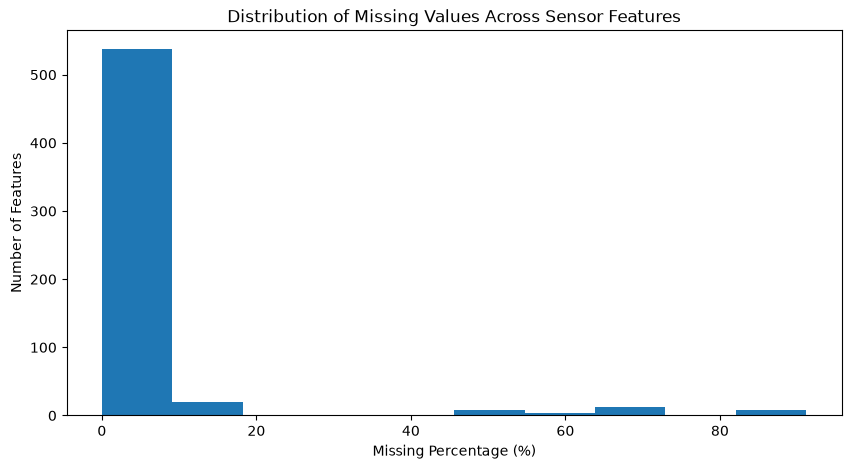

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    missing_percent[x.columns],
    bins=10
)

plt.title("Distribution of Missing Values Across Sensor Features")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Features")

plt.show()

### 19. Remove >90% Missing Features

In [42]:
high_missing_features = missing_percent[
    missing_percent > 90
].index

In [43]:
high_missing_features

Index(['sensor_158', 'sensor_159', 'sensor_294', 'sensor_293'], dtype='str')

In [44]:
print("Features to remove:", len(high_missing_features))
print(high_missing_features.tolist())

Features to remove: 4
['sensor_158', 'sensor_159', 'sensor_294', 'sensor_293']


In [45]:
df_clean = df.drop(columns=high_missing_features)

In [46]:
print("Original shape:", df.shape)
print("New shape:", df_clean.shape)

Original shape: (1567, 593)
New shape: (1567, 589)


### 20. Remaining missing values

In [47]:
remaining_missing = df_clean.isnull().sum()

remaining_missing = (
    remaining_missing[remaining_missing > 0]
    .sort_values(ascending=False)
)

print("Features still containing missing values:",
      len(remaining_missing))

print("Total remaining missing values:",
      remaining_missing.sum())

remaining_missing.head(20)

Features still containing missing values: 534
Total remaining missing values: 36235


sensor_221    1341
sensor_359    1341
sensor_086    1341
sensor_493    1341
sensor_112    1018
sensor_246    1018
sensor_247    1018
sensor_383    1018
sensor_385    1018
sensor_110    1018
sensor_111    1018
sensor_517    1018
sensor_519    1018
sensor_518    1018
sensor_245    1018
sensor_384    1018
sensor_579     949
sensor_581     949
sensor_580     949
sensor_582     949
dtype: int64

In [48]:
df_clean = df_clean.drop(columns=["target_numeric"])

Separate x and y again

In [49]:
x=df_clean.drop(columns=['target','timestamp'])
y=df_clean['target']

In [50]:
print(x.shape)
print(y.shape)

(1567, 586)
(1567,)


###  21 — Train/Test Split

In [51]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

X_train: (1253, 586)
X_test: (314, 586)

Training target:
target
Pass    1170
Fail      83
Name: count, dtype: int64

Testing target:
target
Pass    293
Fail     21
Name: count, dtype: int64


### Avoiding Data Leakage

Data leakage occurs when information from the test data accidentally influences the training process.

For example, calculating the median using the entire dataset before splitting would allow information from the test set to influence the training process.

Therefore, our preprocessing follows this rule:

Training data
→ Learn preprocessing parameters

Test data
→ Only apply the learned parameters

The same principle is followed for:

- Imputation
- Feature Selection
- Scaling

###  22 — Median Imputation

In [53]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [54]:
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed = imputer.transform(x_test)

In [55]:
x_train_imputed = pd.DataFrame(
    x_train_imputed,
    columns=x_train.columns,
    index=x_train.index
)

x_test_imputed = pd.DataFrame(
    x_test_imputed,
    columns=x_test.columns,
    index=x_test.index
)

In [56]:
print("Missing in X_train:",
      x_train_imputed.isnull().sum().sum())

print("Missing in X_test:",
      x_test_imputed.isnull().sum().sum())

Missing in X_train: 0
Missing in X_test: 0


###  23 — Outlier handling

Potential outliers were identified using boxplots and statistical analysis. Since extreme sensor readings may represent genuine process conditions or failure-related signals, observations were not indiscriminately removed.

###  24 — Feature selection

In [57]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=50
)

x_train_selected = selector.fit_transform(
    x_train_imputed,
    y_train
)

x_test_selected = selector.transform(
    x_test_imputed
)

c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  97 141 149 176 177 184 187 188 189 190 191 192
 224 227 228 229 230 231 232 233 234 235 238 239 240 241 254 255 256 257
 258 259 260 261 262 263 264 274 282 309 310 311 318 321 322 323 324 325
 326 360 365 366 367 368 369 370 371 374 375 376 377 390 391 392 393 394
 395 396 397 398 399 400 410 418 445 446 447 454 457 458 459 460 461 462
 477 494 497 498 499 500 501 502 503 504 505 508 509 510 511 524 525 526
 527 528 529 530 531 532 533 534] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [58]:
print("Before feature selection:", x_train_imputed.shape)
print("After feature selection:", x_train_selected.shape)

Before feature selection: (1253, 586)
After feature selection: (1253, 50)


which features were selected

In [59]:
selected_features = x_train.columns[
    selector.get_support()
]

print("Selected features:")
print(selected_features.tolist())

Selected features:
['sensor_015', 'sensor_022', 'sensor_023', 'sensor_029', 'sensor_034', 'sensor_060', 'sensor_064', 'sensor_065', 'sensor_080', 'sensor_104', 'sensor_112', 'sensor_115', 'sensor_122', 'sensor_123', 'sensor_124', 'sensor_125', 'sensor_126', 'sensor_128', 'sensor_130', 'sensor_131', 'sensor_134', 'sensor_160', 'sensor_161', 'sensor_164', 'sensor_165', 'sensor_166', 'sensor_197', 'sensor_198', 'sensor_206', 'sensor_211', 'sensor_248', 'sensor_250', 'sensor_295', 'sensor_296', 'sensor_299', 'sensor_300', 'sensor_301', 'sensor_317', 'sensor_333', 'sensor_334', 'sensor_342', 'sensor_349', 'sensor_431', 'sensor_432', 'sensor_435', 'sensor_436', 'sensor_437', 'sensor_470', 'sensor_478', 'sensor_511']


Now let's see the scores:

In [60]:
feature_scores = pd.DataFrame({
    "Feature": x_train.columns,
    "F_Score": selector.scores_,
    "Selected": selector.get_support()
})

feature_scores = feature_scores.sort_values(
    by="F_Score",
    ascending=False
)

feature_scores.head(20)

,Feature,F_Score,Selected
59,sensor_060,37.977531,True
103,sensor_104,31.632331,True
506,sensor_511,24.924438,True
344,sensor_349,23.647677,True
427,sensor_432,19.853846,True
28,sensor_029,17.856180,True
21,sensor_022,17.826968,True
430,sensor_435,16.956383,True
426,sensor_431,16.570442,True
431,sensor_436,16.398132,True


### Why do we perform Feature Selection?

The original dataset contains hundreds of sensor features.

Using every feature can:

- Increase model complexity
- Increase computational cost
- Include irrelevant information
- Increase the risk of overfitting
- Make the model harder to interpret

Therefore, we reduce the feature space to the most informative features.

We use:

**SelectKBest + ANOVA F-test (`f_classif`)**

The ANOVA F-test evaluates how strongly each feature differs between the Pass and Fail classes.

A higher F-score indicates that the feature shows stronger class separation.

We selected the top **50 features** as an initial feature subset.

An initial subset of 50 features was selected using ANOVA F-test, with the final feature count to be validated through model performance.

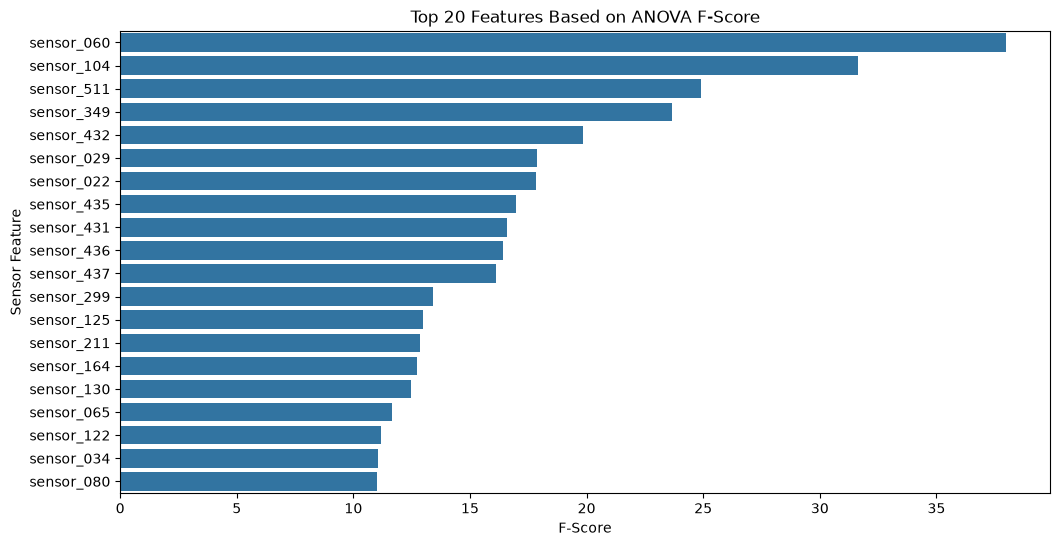

In [61]:
top_20 = feature_scores.head(20)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_20,
    x="F_Score",
    y="Feature"
)

plt.title("Top 20 Features Based on ANOVA F-Score")
plt.xlabel("F-Score")
plt.ylabel("Sensor Feature")

plt.show()

###  25 — Feature scaling

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_selected)
x_test_scaled = scaler.transform(x_test_selected)

# Step 3 -  Model Building, Evaluation & Deployment

### 26 Encode y_train and y_test

In [63]:
y_train_encoded=y_train.map({
    "Pass": 0,
    "Fail": 1
}
)
y_test_encoded=y_test.map({
    "Pass": 0,
    "Fail": 1
})

First Model - Train Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    x_train_scaled,
    y_train_encoded
)

y_pred_lr = logistic_model.predict(x_test_scaled)

print("Logistic Regression completed")

Logistic Regression completed


In [65]:
print("Train Accuracy:", logistic_model.score(x_train_scaled, y_train_encoded)*100)
print("Test Accuracy :", logistic_model.score(x_test_scaled, y_test_encoded)*100)

Train Accuracy: 93.77494014365523
Test Accuracy : 92.67515923566879


In [66]:
from sklearn.metrics import classification_report, confusion_matrix


print(classification_report(
    y_test_encoded,
    y_pred_lr,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.94      0.99      0.96       293
        Fail       0.25      0.05      0.08        21

    accuracy                           0.93       314
   macro avg       0.59      0.52      0.52       314
weighted avg       0.89      0.93      0.90       314



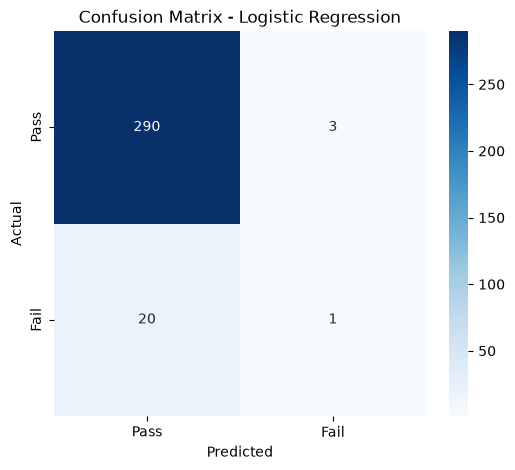

In [67]:
cm = confusion_matrix(
    y_test_encoded,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [68]:
from sklearn.metrics import roc_auc_score

y_prob_lr = logistic_model.predict_proba(x_test_scaled)[:, 1]

roc_auc_lr = roc_auc_score(
    y_test_encoded,
    y_prob_lr
)

print("ROC-AUC:", roc_auc_lr)

ROC-AUC: 0.7552413456850317


LOGISTIC REGRESSION RESULT

Train Accuracy: 93.77494014365523

Test Accuracy : 92.67515923566879

confusion matrix:

        [290   3]
        [ 20   1]

ROC-AUC: 0.7552413456850317
        

Second Model - KNN(K Nearest Neighbor)

In [69]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    x_train_scaled,
    y_train_encoded
)

print("KNN model trained successfully")

KNN model trained successfully


In [70]:
y_pred_knn = knn_model.predict(x_test_scaled)

In [71]:
print("Train Accuracy:", knn_model.score(x_train_scaled, y_train_encoded))
print("Test Accuracy :", knn_model.score(x_test_scaled, y_test_encoded))

Train Accuracy: 0.936951316839585
Test Accuracy : 0.9267515923566879


In [72]:
print(classification_report(
    y_test_encoded,
    y_pred_knn,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.93      0.99      0.96       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [73]:
y_prob_knn = knn_model.predict_proba(x_test_scaled)[:, 1]

roc_auc_knn = roc_auc_score(
    y_test_encoded,
    y_prob_knn
)

print("ROC-AUC:", roc_auc_knn)

ROC-AUC: 0.596375751665854


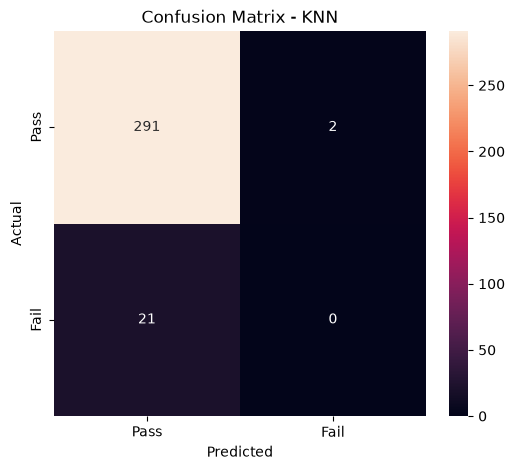

In [74]:
cm_knn = confusion_matrix(
    y_test_encoded,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

KNN Result

Train Accuracy: 0.936951316839585

Test Accuracy : 0.9267515923566879

Confusion Matrix:

       [291   2]
       [ 21   0]

ROC-AUC: 0.596375751665854

Third Model - Decision Tree

In [75]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    x_train_selected,
    y_train_encoded
)

y_pred_dt = dt_model.predict(x_test_selected)

print("Train Accuracy:", dt_model.score(x_train_selected, y_train_encoded))
print("Test Accuracy :", dt_model.score(x_test_selected, y_test_encoded))

Train Accuracy: 1.0
Test Accuracy : 0.8630573248407644


In [76]:
print(classification_report(
    y_test_encoded,
    y_pred_dt,
    target_names=["Pass", "Fail"]
))

y_prob_dt = dt_model.predict_proba(x_test_selected)[:, 1]

print("ROC-AUC:", roc_auc_score(
    y_test_encoded,
    y_prob_dt
))

              precision    recall  f1-score   support

        Pass       0.93      0.92      0.93       293
        Fail       0.04      0.05      0.04        21

    accuracy                           0.86       314
   macro avg       0.49      0.48      0.49       314
weighted avg       0.87      0.86      0.87       314

ROC-AUC: 0.4845603770518446


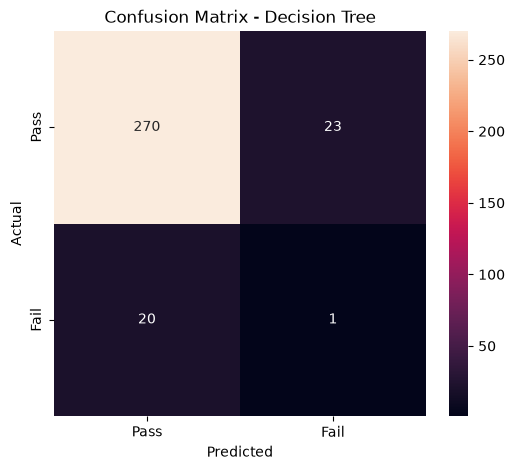

In [77]:
cm_dt=confusion_matrix(y_test_encoded,y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Decision Tree Result

Train Accuracy: 1.0

Test Accuracy : 0.8630573248407644

Confusion Matrix:

            [270  23]
            [20    1]

ROC-AUC: 0.4845603770518446

Fourth Model - Random Forest


In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    x_train_selected,
    y_train_encoded
)

y_pred_rf = rf_model.predict(x_test_selected)

print("Train Accuracy:", rf_model.score(x_train_selected, y_train_encoded))
print("Test Accuracy :", rf_model.score(x_test_selected, y_test_encoded))

Train Accuracy: 1.0
Test Accuracy : 0.9363057324840764


In [79]:
print(classification_report(
    y_test_encoded,
    y_pred_rf,
    target_names=["Pass", "Fail"]
))

y_prob_rf = rf_model.predict_proba(x_test_selected)[:, 1]

print("ROC-AUC:", roc_auc_score(
    y_test_encoded,
    y_prob_rf
))

              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
        Fail       1.00      0.05      0.09        21

    accuracy                           0.94       314
   macro avg       0.97      0.52      0.53       314
weighted avg       0.94      0.94      0.91       314

ROC-AUC: 0.702909150008126


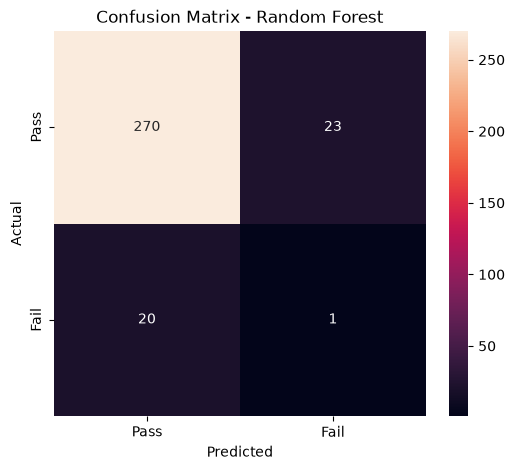

In [80]:
cm_rf=confusion_matrix(y_test_encoded,y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

Random Forest Result

Train Accuracy: 1.0

Test Accuracy : 0.9363057324840764

Confusion Matrix:

            [270  23]
            [20    1]

ROC-AUC: 0.702909150008126
            

Fifth Model - SVM

In [81]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    x_train_scaled,
    y_train_encoded
)

y_pred_svm = svm_model.predict(x_test_scaled)

print("Train Accuracy:", svm_model.score(x_train_scaled, y_train_encoded))
print("Test Accuracy :", svm_model.score(x_test_scaled, y_test_encoded))

c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Train Accuracy: 0.9385474860335196
Test Accuracy : 0.9331210191082803


In [82]:
print(classification_report(
    y_test_encoded,
    y_pred_svm,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [83]:
y_prob_svm = svm_model.predict_proba(x_test_scaled)[:, 1]

roc_auc_svm = roc_auc_score(
    y_test_encoded,
    y_prob_svm
)

print("ROC-AUC:", roc_auc_svm)

ROC-AUC: 0.7027466276613034


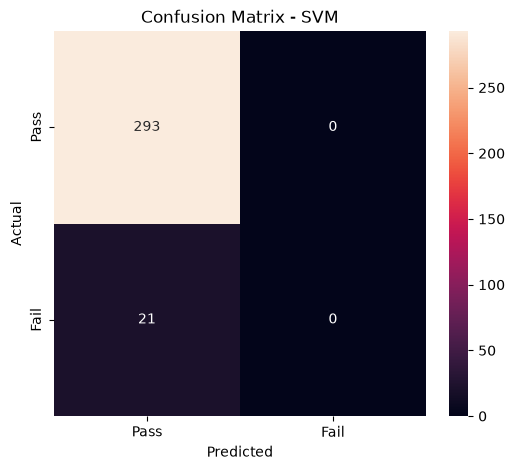

In [84]:
cm_svm = confusion_matrix(
    y_test_encoded,
    y_pred_svm
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

SVM Result

Train Accuracy: 0.9385474860335196

Test Accuracy : 0.9331210191082803

Confusion Matrix:

            [293  0]
            [21   0]

ROC-AUC: 0.7027466276613034

## Big problem

All 5 models struggle with Fail class.

Because of imbalanced target

# Class Imbalance — The Main Challenge

After comparing the first five models, we found a common problem.

Most models achieved high overall accuracy but performed poorly on the Fail class.

The reason is the strong imbalance between Pass and Fail observations.

The model sees many more Pass examples during training.

As a result, predicting Pass most of the time can produce high accuracy.

### Why is this a problem?

In manufacturing quality prediction, missing a potential failure can be more important than incorrectly flagging a Pass observation.

Therefore, we need to investigate techniques that give more attention to the minority Fail class.

We will test two approaches:

1. **SMOTE**
2. **Class Weighting**

In [85]:
from imblearn.over_sampling import SMOTE

In [86]:
smote = SMOTE(
    random_state=42
)

x_train_balanced, y_train_balanced = smote.fit_resample(
    x_train_scaled,
    y_train_encoded
)

print("Before SMOTE:")
print(y_train_encoded.shape)

print("\nAfter SMOTE:")
print(y_train_balanced.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
(1253,)

After SMOTE:
(2340,)

Class distribution after SMOTE:
target
0    1170
1    1170
Name: count, dtype: int64


Logistic Regression with SMOTE

In [87]:
logistic_smote = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_smote.fit(
    x_train_balanced,
    y_train_balanced
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [88]:
y_pred_lr_smote = logistic_smote.predict(x_test_scaled)
print("Train Accuracy:",
      logistic_smote.score(x_train_balanced, y_train_balanced))

print("Test Accuracy:",
      logistic_smote.score(x_test_scaled, y_test_encoded))

Train Accuracy: 0.7858974358974359
Test Accuracy: 0.7547770700636943


In [89]:
print(classification_report(
    y_test_encoded,
    y_pred_lr_smote,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.96      0.77      0.85       293
        Fail       0.14      0.52      0.22        21

    accuracy                           0.75       314
   macro avg       0.55      0.65      0.54       314
weighted avg       0.90      0.75      0.81       314



In [90]:
y_prob_lr_smote = logistic_smote.predict_proba(x_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test_encoded, y_prob_lr_smote))

ROC-AUC: 0.7370388428408906


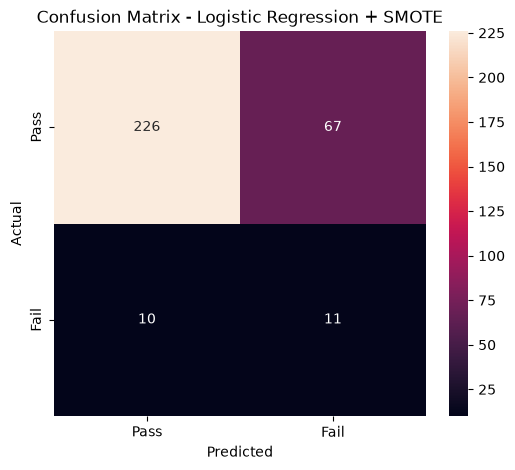

In [91]:
cm_lr_smote = confusion_matrix(
    y_test_encoded,
    y_pred_lr_smote
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_smote,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression + SMOTE")

plt.show()

SMOTE Logistic Regression Result

Train Accuracy: 0.7858974358974359

Test Accuracy: 0.7547770700636943

Confusion Matrix:

            [226  67]
            [10   11]

ROC-AUC: 0.7370388428408906

Random Forest with SMOTE

In [92]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(
    x_train_balanced,
    y_train_balanced
)

y_pred_rf_smote = rf_smote.predict(x_test_scaled)

print("Train Accuracy:",
      rf_smote.score(x_train_balanced, y_train_balanced))

print("Test Accuracy:",
      rf_smote.score(x_test_scaled, y_test_encoded))

Train Accuracy: 1.0
Test Accuracy: 0.9235668789808917


In [93]:
print(classification_report(
    y_test_encoded,
    y_pred_rf_smote,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.94      0.98      0.96       293
        Fail       0.29      0.10      0.14        21

    accuracy                           0.92       314
   macro avg       0.61      0.54      0.55       314
weighted avg       0.89      0.92      0.91       314



In [94]:
y_prob_rf_smote = rf_smote.predict_proba(
    x_test_scaled
)[:, 1]

print("ROC-AUC:",
      roc_auc_score(
          y_test_encoded,
          y_prob_rf_smote
      ))

ROC-AUC: 0.7142857142857143


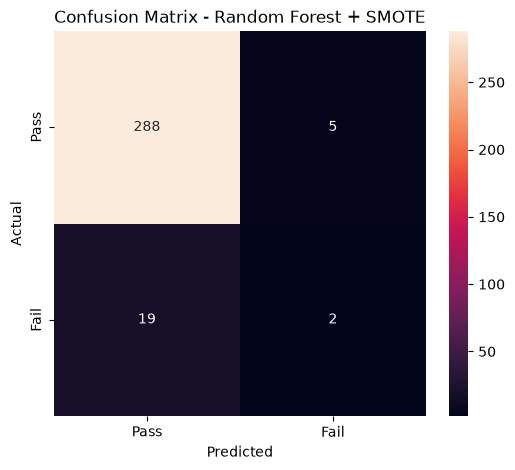

In [95]:
cm_rf_smote = confusion_matrix(
    y_test_encoded,
    y_pred_rf_smote
)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf_smote,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest + SMOTE")

plt.show()

SMOTE Random Forest Result

Train Accuracy: 1.0

Test Accuracy: 0.9235668789808917

Confusion Matrix:

            [288   5]
            [19    2]

ROC-AUC: 0.7142857142857143

SVM with SMOTE

In [96]:
svm_smote = SVC(
    probability=True,
    random_state=42
)

svm_smote.fit(
    x_train_balanced,
    y_train_balanced
)

y_pred_svm_smote = svm_smote.predict(x_test_scaled)

print("Train Accuracy:",
      svm_smote.score(x_train_balanced, y_train_balanced))

print("Test Accuracy:",
      svm_smote.score(x_test_scaled, y_test_encoded))

c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Train Accuracy: 0.9055555555555556
Test Accuracy: 0.8057324840764332


In [97]:
print(classification_report(
    y_test_encoded,
    y_pred_svm_smote,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.95      0.84      0.89       293
        Fail       0.13      0.33      0.19        21

    accuracy                           0.81       314
   macro avg       0.54      0.59      0.54       314
weighted avg       0.89      0.81      0.84       314



In [98]:
y_prob_svm_smote = svm_smote.predict_proba(
    x_test_scaled
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_encoded,
        y_prob_svm_smote
    )
)

ROC-AUC: 0.7276125467251748


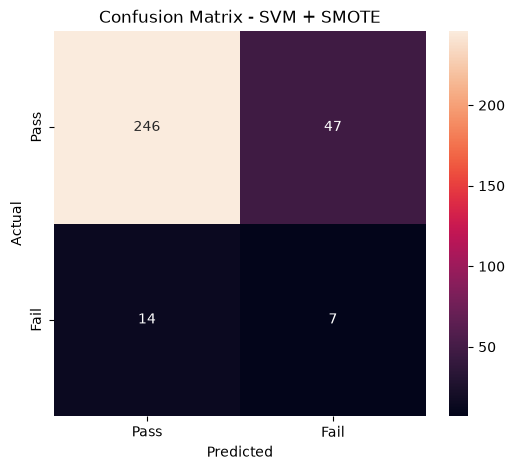

In [99]:
cm_svm_smote = confusion_matrix(
    y_test_encoded,
    y_pred_svm_smote
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_smote,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM + SMOTE")

plt.show()

SVM SMOTE Result

Train Accuracy: 0.9055555555555556

Test Accuracy: 0.8057324840764332

Conusion Matrix:

            [246  47]
            [14    7]

ROC-AUC: 0.7276125467251748

### SMOTE Results

After applying SMOTE:

- Logistic Regression improved Fail recall substantially.
- SVM also detected more Fail observations.
- Random Forest showed only a small improvement in Fail detection.

However, improving Fail detection came with a trade-off.

The models started predicting more Pass observations as Fail.

This reduced overall accuracy.

Therefore:

> SMOTE improves minority-class learning, but it does not automatically produce a better overall model.

We need to consider the business objective and multiple evaluation metrics rather than accuracy alone.

## Handling Class Imbalance with Class Weighting

Another approach is to change how the model treats the classes.

With:

`class_weight="balanced"`

the model automatically gives more importance to the minority class.

This allows the model to pay more attention to Fail observations without creating synthetic data.

We test class weighting with Logistic Regression and Random Forest.

Logistic Regression + class_weight="balanced"

In [100]:
logistic_balanced = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_balanced.fit(
    x_train_scaled,
    y_train_encoded
)

y_pred_lr_balanced = logistic_balanced.predict(
    x_test_scaled
)

print("Train Accuracy:",
      logistic_balanced.score(
          x_train_scaled,
          y_train_encoded
      ))

print("Test Accuracy:",
      logistic_balanced.score(
          x_test_scaled,
          y_test_encoded
      ))

Train Accuracy: 0.770949720670391
Test Accuracy: 0.7611464968152867


In [101]:
print(classification_report(
    y_test_encoded,
    y_pred_lr_balanced,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.96      0.77      0.86       293
        Fail       0.15      0.57      0.24        21

    accuracy                           0.76       314
   macro avg       0.56      0.67      0.55       314
weighted avg       0.91      0.76      0.82       314



In [102]:
y_prob_lr_balanced = logistic_balanced.predict_proba(
    x_test_scaled
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_encoded,
        y_prob_lr_balanced
    )
)

ROC-AUC: 0.7375264098813586


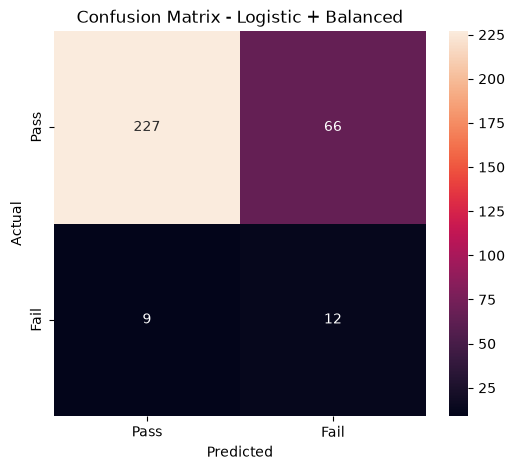

In [103]:
cm_lr_balanced = confusion_matrix(
    y_test_encoded,
    y_pred_lr_balanced
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_balanced,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic + Balanced")

plt.show()

Logistic + "Balanced" Result

Train Accuracy: 0.770949720670391

Test Accuracy: 0.7611464968152867

Confusion Matrix:

            [227   66]
            [9     12]

ROC-AUC: 0.7375264098813586

Random Forest + Balanced

In [104]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(
    x_train_selected,
    y_train_encoded
)

y_pred_rf_balanced = rf_balanced.predict(
    x_test_selected
)

print("Train Accuracy:",
      rf_balanced.score(
          x_train_selected,
          y_train_encoded
      ))

print("Test Accuracy:",
      rf_balanced.score(
          x_test_selected,
          y_test_encoded
      ))

Train Accuracy: 1.0
Test Accuracy: 0.9331210191082803


In [105]:
print(classification_report(
    y_test_encoded,
    y_pred_rf_balanced,
    target_names=["Pass", "Fail"]
))

              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
        Fail       0.50      0.05      0.09        21

    accuracy                           0.93       314
   macro avg       0.72      0.52      0.53       314
weighted avg       0.91      0.93      0.91       314



In [106]:
y_prob_rf_balanced = rf_balanced.predict_proba(
    x_test_selected
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_encoded,
        y_prob_rf_balanced
    )
)

ROC-AUC: 0.7237932715748415


[[292   1]
 [ 20   1]]


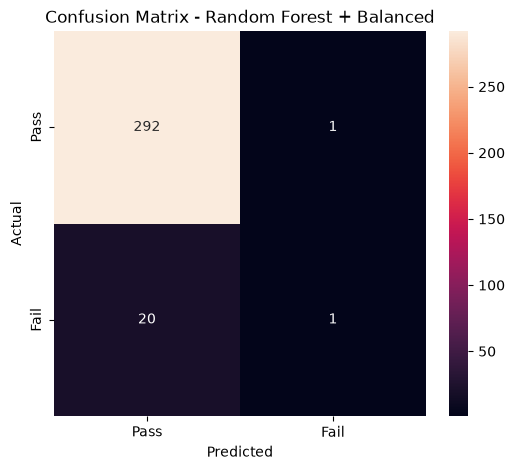

In [107]:
cm_rf_balanced = confusion_matrix(
    y_test_encoded,
    y_pred_rf_balanced
)

print(cm_rf_balanced)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf_balanced,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest + Balanced")

plt.show()

Random Forest + Balanced Result

Train Accuracy: 1.0

Test Accuracy: 0.9331210191082803

Confusion Matrix:

                [292   1]
                [20    1]

ROC-AUC: 0.7237932715748415

### Class Weighting Results

Logistic Regression with balanced class weights detected more Fail observations than the original Logistic Regression model.

The Fail recall improved significantly compared with the original model.

However, this came with a reduction in overall accuracy because more Pass observations were classified as Fail.

This shows the fundamental trade-off:

**Higher Fail detection ↔ More false alarms**

For a manufacturing application, this trade-off must be considered carefully.

# Threshold Tuning

Normally, a binary classification model uses a probability threshold of **0.5**.

For example:

- Probability < 0.5 → Pass
- Probability ≥ 0.5 → Fail

However, the default threshold is not always the best choice for a business problem.

Our objective is to improve the detection of the minority Fail class.

Therefore, we evaluate different probability thresholds using the validation data.

We compare thresholds such as:

0.3, 0.4, 0.5, 0.6, 0.7

For each threshold, we examine:

- Accuracy
- Fail Precision
- Fail Recall
- Fail F1-score

We select the threshold based on the validation performance rather than choosing it using the test set.

Threshold Tuning

In [108]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_lr_balanced >= threshold
    ).astype(int)

    print(f"\n===== Threshold: {threshold} =====")

    print(classification_report(
        y_test_encoded,
        y_pred_threshold,
        target_names=["Pass", "Fail"],
        zero_division=0
    ))


===== Threshold: 0.2 =====
              precision    recall  f1-score   support

        Pass       0.98      0.43      0.60       293
        Fail       0.10      0.90      0.18        21

    accuracy                           0.46       314
   macro avg       0.54      0.67      0.39       314
weighted avg       0.93      0.46      0.57       314


===== Threshold: 0.3 =====
              precision    recall  f1-score   support

        Pass       0.98      0.59      0.74       293
        Fail       0.12      0.81      0.22        21

    accuracy                           0.61       314
   macro avg       0.55      0.70      0.48       314
weighted avg       0.92      0.61      0.70       314


===== Threshold: 0.4 =====
              precision    recall  f1-score   support

        Pass       0.97      0.68      0.80       293
        Fail       0.14      0.71      0.23        21

    accuracy                           0.68       314
   macro avg       0.55      0.70      0.52 

### Threshold Selection

The validation results were compared across multiple thresholds.

A threshold of **0.7** was selected because it provided the strongest Fail F1-score among the tested thresholds while maintaining a reasonable balance between precision and recall.

Once selected, the threshold was **locked**.

We do not continue changing the threshold based on the test results.

This helps keep the final test evaluation separate from the model-selection process.

Final Validation

In [109]:
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

print("Training shape:", x_train_final.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

print("\nTraining distribution:")
print(y_train_final.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test_encoded.value_counts())

Training shape: (1002, 586)
Validation shape: (251, 586)
Test shape: (314, 586)

Training distribution:
target
0    936
1     66
Name: count, dtype: int64

Validation distribution:
target
0    234
1     17
Name: count, dtype: int64

Test distribution:
target
0    293
1     21
Name: count, dtype: int64


Final preprocessing

In [110]:
imputer_final = SimpleImputer(strategy="median")

x_train_final_imputed = imputer_final.fit_transform(
    x_train_final
)

x_val_imputed = imputer_final.transform(
    x_val
)

x_test_imputed = imputer_final.transform(
    x_test
)

print("Missing values in training:",
      np.isnan(x_train_final_imputed).sum())

print("Missing values in validation:",
      np.isnan(x_val_imputed).sum())

print("Missing values in test:",
      np.isnan(x_test_imputed).sum())

Missing values in training: 0
Missing values in validation: 0
Missing values in test: 0


Feature Selection

In [111]:
selector_final = SelectKBest(
    score_func=f_classif,
    k=50
)

x_train_final_selected = selector_final.fit_transform(
    x_train_final_imputed,
    y_train_final
)

x_val_selected = selector_final.transform(
    x_val_imputed
)

x_test_selected = selector_final.transform(
    x_test_imputed
)

print("Original features:", x_train_final_imputed.shape[1])
print("Selected features:", x_train_final_selected.shape[1])

Original features: 586
Selected features: 50


c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  97 141 149 176 177 184 187 188 189 190 191 192
 224 227 228 229 230 231 232 233 234 235 238 239 240 241 254 255 256 257
 258 259 260 261 262 263 264 274 282 309 310 311 318 321 322 323 324 325
 326 360 365 366 367 368 369 370 371 374 375 376 377 390 391 392 393 394
 395 396 397 398 399 400 410 418 445 446 447 454 457 458 459 460 461 462
 477 494 497 498 499 500 501 502 503 504 505 508 509 510 511 524 525 526
 527 528 529 530 531 532 533 534] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [112]:
scaler_final = StandardScaler()

x_train_final_scaled = scaler_final.fit_transform(
    x_train_final_selected
)

x_val_scaled = scaler_final.transform(
    x_val_selected
)

x_test_final_scaled = scaler_final.transform(
    x_test_selected
)

print("Training:", x_train_final_scaled.shape)
print("Validation:", x_val_scaled.shape)
print("Test:", x_test_final_scaled.shape)

Training: (1002, 50)
Validation: (251, 50)
Test: (314, 50)


Train our candidate model

Logistic Regression + Balanced

In [113]:
final_candidate = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

final_candidate.fit(
    x_train_final_scaled,
    y_train_final
)

print("Training completed.")

Training completed.


In [114]:
y_val_prob = final_candidate.predict_proba(
    x_val_scaled
)[:, 1]

print(y_val_prob[:10])

[0.29525221 0.44132824 0.21182399 0.30438084 0.40143352 0.81802975
 0.24573624 0.63267711 0.1806315  0.30242231]


Lock the threshold

In [115]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    print(f"\n===== Threshold: {threshold} =====")

    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_val,
        y_val_pred,
        target_names=["Pass", "Fail"],
        zero_division=0
    ))


===== Threshold: 0.3 =====
Confusion Matrix:
[[124 110]
 [  4  13]]

Classification Report:
              precision    recall  f1-score   support

        Pass       0.97      0.53      0.69       234
        Fail       0.11      0.76      0.19        17

    accuracy                           0.55       251
   macro avg       0.54      0.65      0.44       251
weighted avg       0.91      0.55      0.65       251


===== Threshold: 0.4 =====
Confusion Matrix:
[[153  81]
 [  5  12]]

Classification Report:
              precision    recall  f1-score   support

        Pass       0.97      0.65      0.78       234
        Fail       0.13      0.71      0.22        17

    accuracy                           0.66       251
   macro avg       0.55      0.68      0.50       251
weighted avg       0.91      0.66      0.74       251


===== Threshold: 0.5 =====
Confusion Matrix:
[[171  63]
 [  6  11]]

Classification Report:
              precision    recall  f1-score   support

        Pass

The classification threshold was selected using the validation set, with emphasis on balancing minority-class Fail precision and recall through the Fail F1-score. A threshold of 0.7 was selected and then locked before evaluating the test set.

In [116]:
selected_threshold = 0.7

print("Selected Threshold:", selected_threshold)

Selected Threshold: 0.7


Step 1 — Combine Train + Validation

In [117]:
x_dev = pd.concat([x_train_final, x_val], axis=0)
y_dev = pd.concat([y_train_final, y_val], axis=0)

print("Development X:", x_dev.shape)
print("Development y:", y_dev.shape)

Development X: (1253, 586)
Development y: (1253,)


Step 2 — Rebuild preprocessing on the combined data

In [118]:
imputer_final = SimpleImputer(strategy="median")

x_dev_imputed = imputer_final.fit_transform(x_dev)
X_test_imputed = imputer_final.transform(x_test)

print("Train missing:", np.isnan(x_dev_imputed).sum())
print("Test missing:", np.isnan(x_test_imputed).sum())

Train missing: 0
Test missing: 0


Step 3 — Feature Selection

In [119]:
selector_final = SelectKBest(
    score_func=f_classif,
    k=50
)

x_dev_selected = selector_final.fit_transform(
    x_dev_imputed,
    y_dev
)

X_test_selected = selector_final.transform(
    X_test_imputed
)

print("Before feature selection:", x_dev_imputed.shape)
print("After feature selection:", x_dev_selected.shape)

Before feature selection: (1253, 586)
After feature selection: (1253, 50)


c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  97 141 149 176 177 184 187 188 189 190 191 192
 224 227 228 229 230 231 232 233 234 235 238 239 240 241 254 255 256 257
 258 259 260 261 262 263 264 274 282 309 310 311 318 321 322 323 324 325
 326 360 365 366 367 368 369 370 371 374 375 376 377 390 391 392 393 394
 395 396 397 398 399 400 410 418 445 446 447 454 457 458 459 460 461 462
 477 494 497 498 499 500 501 502 503 504 505 508 509 510 511 524 525 526
 527 528 529 530 531 532 533 534] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Step 4 — Scaling

In [120]:
scaler_final = StandardScaler()

x_dev_scaled = scaler_final.fit_transform(x_dev_selected)
x_test_final_scaled = scaler_final.transform(x_test_selected)

print("Development:", x_dev_scaled.shape)
print("Test:", x_test_final_scaled.shape)

Development: (1253, 50)
Test: (314, 50)


Step 5 — Train the final model

In [121]:
final_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

final_model.fit(
    x_dev_scaled,
    y_dev
)

print("Final model trained successfully.")

Final model trained successfully.


Step 6 — Predict on the untouched test set

In [122]:
y_test_prob = final_model.predict_proba(x_test_final_scaled)[:, 1]

# Apply the locked threshold
y_test_pred = (y_test_prob >= selected_threshold).astype(int)

print("Predictions generated successfully.")
print("Threshold used:", selected_threshold)

Predictions generated successfully.
Threshold used: 0.7


In [123]:
pred=final_model.predict(x_test_final_scaled)

In [124]:
cm = confusion_matrix(y_test_encoded, pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[286   7]
 [ 19   2]]


[[286   7]
 [ 19   2]]


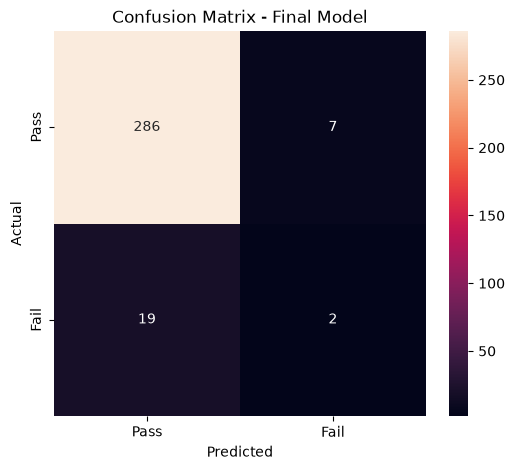

In [125]:
final_cm = confusion_matrix(y_test_encoded, pred)

print(final_cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")

plt.show()

### Final Model Evaluation — Interpretation

The final model demonstrates that predicting semiconductor manufacturing failures is a challenging problem because the Fail class is extremely small compared with the Pass class.

The model can identify many Pass observations correctly, but Fail detection remains limited.

This is an important limitation of the current dataset/model.

Rather than reporting only overall accuracy, we report the class-specific metrics and confusion matrix to make this limitation clear.

### Key Learning

A high accuracy score does not necessarily mean that a model is successful.

For an imbalanced manufacturing problem, the ability to identify the minority Fail class must also be considered.

Future improvements could include:

- More failure examples
- Additional process information
- Advanced imbalance handling
- Hyperparameter tuning
- Cross-validation
- More advanced classification models
- Better domain-specific feature engineering

### Create final production Pipeline

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),

    ("feature_selection", SelectKBest(
        score_func=f_classif,
        k=50
    )),

    ("scaler", StandardScaler()),

    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

### Train the pipeline

In [127]:
final_pipeline.fit(x_dev, y_dev)

print("Final production pipeline trained successfully.")

Final production pipeline trained successfully.


c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  97 141 149 176 177 184 187 188 189 190 191 192
 224 227 228 229 230 231 232 233 234 235 238 239 240 241 254 255 256 257
 258 259 260 261 262 263 264 274 282 309 310 311 318 321 322 323 324 325
 326 360 365 366 367 368 369 370 371 374 375 376 377 390 391 392 393 394
 395 396 397 398 399 400 410 418 445 446 447 454 457 458 459 460 461 462
 477 494 497 498 499 500 501 502 503 504 505 508 509 510 511 524 525 526
 527 528 529 530 531 532 533 534] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Varshini D\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### Save the model + threshold

In [128]:
import joblib

model_bundle = {
    "pipeline": final_pipeline,
    "threshold": 0.7,
    "feature_names": x_dev.columns.tolist()
}

joblib.dump(
    model_bundle,
    "secom_quality_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!


### Verify the saved model

In [129]:
loaded_bundle = joblib.load(
    "secom_quality_model.joblib"
)

print(loaded_bundle.keys())
print("Threshold:", loaded_bundle["threshold"])
print("Number of features:", len(loaded_bundle["feature_names"]))

dict_keys(['pipeline', 'threshold', 'feature_names'])
Threshold: 0.7
Number of features: 586


In [130]:
import json
import pandas as pd

# Load dataset
df_api = pd.read_csv("../data/SECOM_Predictive_Quality.csv")

# Remove target and timestamp
sensor_data = df_api.drop(columns=["target", "timestamp"])

# Remove the same 4 >90% missing features
missing_pct = sensor_data.isna().mean() * 100
features_to_drop = missing_pct[missing_pct > 90].index

sensor_data = sensor_data.drop(columns=features_to_drop)

results = []

for i in range(3):

    input_values = sensor_data.iloc[i].tolist()

    input_values = [
        None if pd.isna(value) else float(value)
        for value in input_values
    ]

    results.append(input_values)

payload = {
    "sensor_values": results
}

print(json.dumps(payload, indent=2))

{
  "sensor_values": [
    [
      3030.93,
      2564.0,
      2187.7333,
      1411.1265,
      1.3602,
      100.0,
      97.6133,
      0.1242,
      1.5005,
      0.0162,
      -0.0034,
      0.9455,
      202.4396,
      0.0,
      7.9558,
      414.871,
      10.0433,
      0.968,
      192.3963,
      12.519,
      1.4026,
      -5419.0,
      2916.5,
      -4043.75,
      751.0,
      0.8955,
      1.773,
      3.049,
      64.2333,
      2.0222,
      0.1632,
      3.5191,
      83.3971,
      9.5126,
      50.617,
      64.2588,
      49.383,
      66.3141,
      86.9555,
      117.5132,
      61.29,
      4.515,
      70.0,
      352.7173,
      10.1841,
      130.3691,
      723.3092,
      1.3072,
      141.2282,
      1.0,
      624.3145,
      218.3174,
      0.0,
      4.592,
      4.841,
      2834.0,
      0.9317,
      0.9484,
      4.7057,
      -1.7264,
      350.9264,
      10.6231,
      108.6427,
      16.1445,
      21.7264,
      29.5367,
      693.7724,
    